# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** B.GNYANASINDHU
**Roll Number:**AP24110011847
**Date:**9/10/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [2]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:* 70/30 has more entorpy than 90/10 because the data i smore shuffeled in that split comaper dto thi 90/10 split


### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [3]:
# Write your answer here
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

parent = entropy([8, 6])
left = entropy([6, 0])
right = entropy([2, 6])

weighted_entropy = (6/14) * left + (8/14) * right
information_gain = parent - weighted_entropy

print('Parent Entropy:', parent)
print('Left Child Entropy:', left)
print('Right Child Entropy:', right)
print('Weighted Entropy After Split:', weighted_entropy)
print('Information Gain:', information_gain)


Parent Entropy: 0.9852281360342515
Left Child Entropy: 0.0
Right Child Entropy: 0.8112781244591328
Weighted Entropy After Split: 0.46358749969093305
Information Gain: 0.5216406363433185


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [6]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [7]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [8]:
# 1. Compute information gain for each attribute
for attribute in ['Outlook', 'Temperature', 'Humidity']:
    print(attribute, ':', round(info_gain(tennis, attribute), 4))

# 2. Find the root attribute
attributes = ['Outlook', 'Temperature', 'Humidity']
root = max(attributes, key=lambda a: info_gain(tennis, a))
print('\nRoot attribute:', root)

# 3. Find the next split for each impure branch
for value, subset in tennis.groupby(root):
    if subset['Play'].nunique() > 1:
        print('\nBranch:', value)

        for attribute in attributes:
            if attribute != root:
                print(attribute, ':', round(info_gain(subset, attribute), 4))

Outlook : 0.2467
Temperature : 0.0292
Humidity : 0.1518

Root attribute: Outlook

Branch: Rain
Temperature : 0.02
Humidity : 0.02

Branch: Sunny
Temperature : 0.571
Humidity : 0.971


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*
as telling pure menas only te node have the all similar values and if we calculate teh entropy for theat node alos we get the avlie as 0

## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


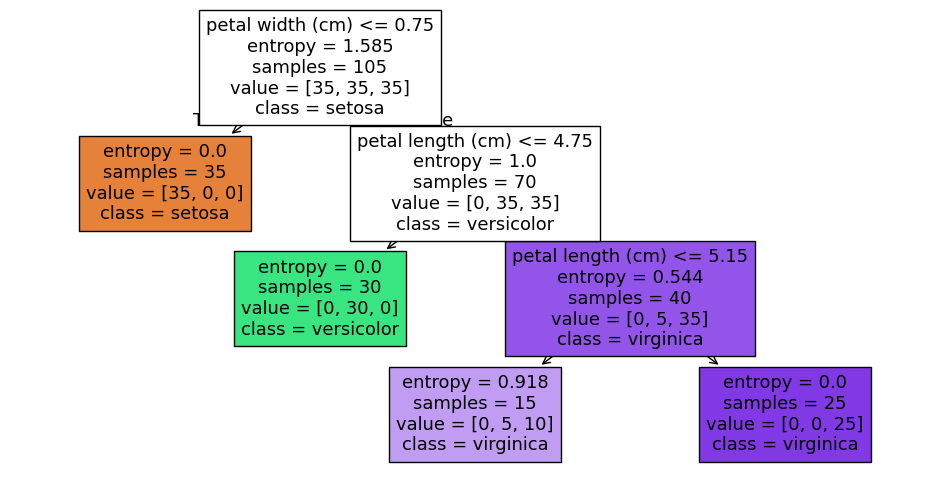

In [9]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


Depth  1: Train Accuracy = 0.6667, Test Accuracy = 0.6667
Depth  2: Train Accuracy = 0.9524, Test Accuracy = 0.9556
Depth  3: Train Accuracy = 0.9524, Test Accuracy = 0.9556
Depth  4: Train Accuracy = 0.9524, Test Accuracy = 0.9333
Depth  5: Train Accuracy = 0.9714, Test Accuracy = 0.9778
Depth  6: Train Accuracy = 0.9810, Test Accuracy = 0.9778
Depth  7: Train Accuracy = 0.9810, Test Accuracy = 0.9778
Depth  8: Train Accuracy = 0.9905, Test Accuracy = 0.9778
Depth  9: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 10: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 11: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 12: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 13: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 14: Train Accuracy = 1.0000, Test Accuracy = 0.9778
Depth 15: Train Accuracy = 1.0000, Test Accuracy = 0.9778


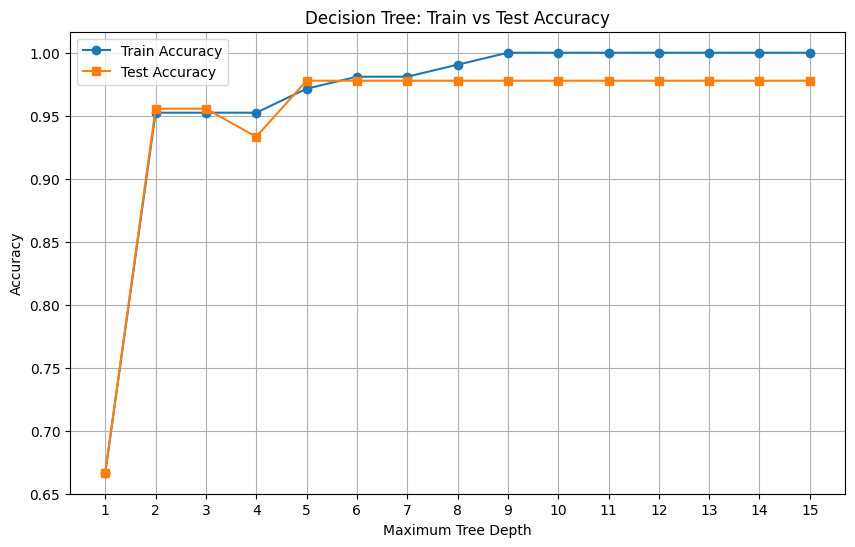

Best depth: 5
Best test accuracy: 0.9778


In [10]:
# Write your answer here
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

depths = range(1, 16)
train_accuracy = []
test_accuracy = []

for depth in depths:
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=1
    )

    tree.fit(X_train, y_train)

    train_accuracy.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, tree.predict(X_test)))

    print(f"Depth {depth:2d}: Train Accuracy = {train_accuracy[-1]:.4f}, Test Accuracy = {test_accuracy[-1]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracy, marker='o', label='Train Accuracy')
plt.plot(depths, test_accuracy, marker='s', label='Test Accuracy')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Train vs Test Accuracy')
plt.xticks(list(depths))
plt.legend()
plt.grid(True)
plt.show()

best_index = test_accuracy.index(max(test_accuracy))
print("Best depth:", list(depths)[best_index])
print("Best test accuracy:", round(test_accuracy[best_index], 4))


**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*in week 6 the knob is k value the k value is 1 the model overfits and k value i high the model underfits whereas in polynomial regression as teh value of n is more teh model overifts and the n value is low the mode underfits


# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [12]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


Test accuracy: 0.8814814814814815
Max depth 3: Test accuracy = 0.5296296296296297
Max depth 6: Test accuracy = 0.8537037037037037
Max depth 10: Test accuracy = 0.8796296296296297


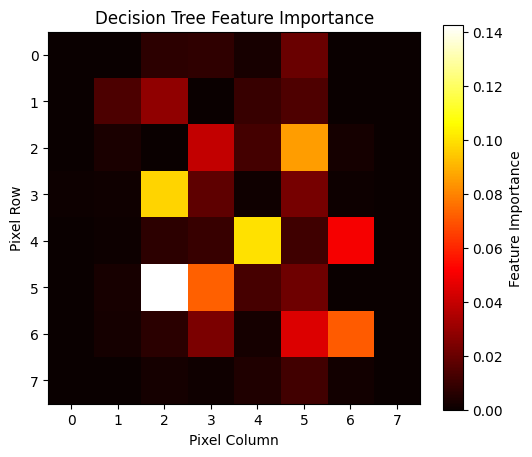

In [13]:
# Write your answer here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(Xd_train, yd_train)

print('Test accuracy:', accuracy_score(yd_test, tree.predict(Xd_test)))

for depth in [3, 6, 10]:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=1
    )
    model.fit(Xd_train, yd_train)
    print(f'Max depth {depth}: Test accuracy =',
          accuracy_score(yd_test, model.predict(Xd_test)))

importance = tree.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 5))
plt.imshow(importance, cmap='hot', interpolation='nearest')
plt.colorbar(label='Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.show()


**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*the decision tree is less accurate on the digits image because it got an accuracy as 88 percent whereas in knn the accuracy is 98


# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [14]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [15]:
# Write your answer here
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text

sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day'
]

labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])

tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(X_text, labels)

print(export_text(tree, feature_names=vocab))

test_sentences = [
    'the striker scored a goal',
    'the phone team scored a match'
]

X_test = np.array([to_vector(s, vocab) for s in test_sentences])

for sentence, prediction in zip(test_sentences, tree.predict(X_test)):
    print(sentence, '->', prediction)

|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

the striker scored a goal -> sports
the phone team scored a match -> sports


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*no,we cannot expectv the same split after addiung the data.training the tree on less datd leads to overfit so we have to trin with more data.

## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
